# 🔗 Hands-On Bab 2 — Konsep Dasar
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini membahas struktur dasar jaringan (simpul, sisi, jenis graf) dan karakteristik kuantitatifnya: **distance, diameter, density,** dan **degree** — lengkap dengan **Latihan Soal Bab 2**.

In [1]:
!pip install -q networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

## 2.1 Struktur & Jenis Graf

Mari bangun keempat jenis graf yang dibahas di buku: tidak berarah, berarah, berbobot, dan bipartite.

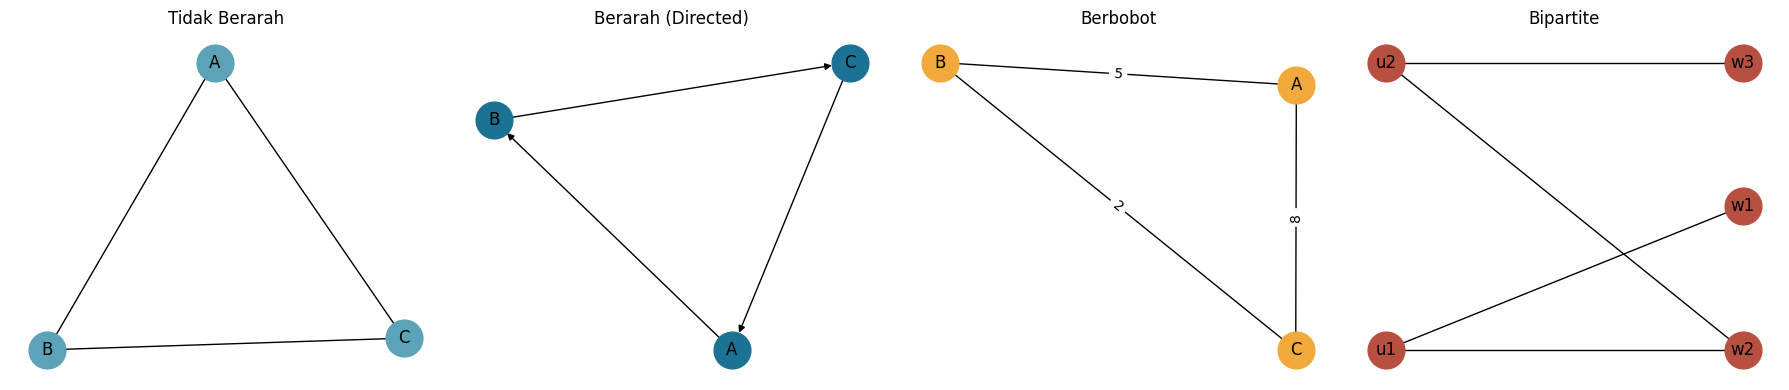

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1. Graf tidak berarah
G1 = nx.Graph([("A","B"), ("B","C"), ("A","C")])
nx.draw(G1, ax=axes[0], with_labels=True, node_color="#5CA3B8", node_size=700)
axes[0].set_title("Tidak Berarah")

# 2. Graf berarah (directed) - contoh followers/following
G2 = nx.DiGraph([("A","B"), ("B","C"), ("C","A")])
nx.draw(G2, ax=axes[1], with_labels=True, node_color="#1C7293", node_size=700, arrows=True)
axes[1].set_title("Berarah (Directed)")

# 3. Graf berbobot
G3 = nx.Graph()
G3.add_weighted_edges_from([("A","B",5), ("B","C",2), ("A","C",8)])
pos3 = nx.spring_layout(G3, seed=1)
nx.draw(G3, pos3, ax=axes[2], with_labels=True, node_color="#F2A93B", node_size=700)
edge_labels = nx.get_edge_attributes(G3, "weight")
nx.draw_networkx_edge_labels(G3, pos3, edge_labels=edge_labels, ax=axes[2])
axes[2].set_title("Berbobot")

# 4. Bipartite graph: mahasiswa - mata kuliah
G4 = nx.Graph()
mhs = ["u1", "u2"]
mk = ["w1", "w2", "w3"]
G4.add_nodes_from(mhs, bipartite=0)
G4.add_nodes_from(mk, bipartite=1)
G4.add_edges_from([("u1","w1"), ("u1","w2"), ("u2","w2"), ("u2","w3")])
pos4 = nx.bipartite_layout(G4, mhs)
nx.draw(G4, pos4, ax=axes[3], with_labels=True, node_color="#B85042", node_size=700)
axes[3].set_title("Bipartite")

plt.tight_layout()
plt.show()

## 2.1.5 Path, Walk, dan Cycle

Gunakan graf A–B–C–D dari buku untuk membedakan ketiga konsep ini.

In [3]:
G_pwc = nx.Graph([("A","B"), ("B","C"), ("C","D"), ("D","A")])

# Path: A -> B -> C -> D (tidak mengulang simpul)
path = ["A", "B", "C", "D"]
print("Apakah A-B-C-D path yang valid?", nx.is_path(G_pwc, path))

# Cycle: A -> B -> C -> D -> A (tertutup)
cycle = list(nx.find_cycle(G_pwc))
print("Cycle yang ditemukan:", cycle)

Apakah A-B-C-D path yang valid? True
Cycle yang ditemukan: [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')]


## 2.2.1 Distance & Geodesic Distance

Reproduksi Gambar 2.6 dari buku: graf dengan A–B langsung dan A–D–C–B.

In [4]:
G_dist = nx.Graph()
G_dist.add_edges_from([("A","B"), ("A","D"), ("D","C"), ("C","B")])

d_ab = nx.shortest_path_length(G_dist, "A", "B")
print(f"d(A,B) = {d_ab}  (sesuai buku: harus = 1)")

path_ab = nx.shortest_path(G_dist, "A", "B")
print("Jalur terpendek A ke B:", path_ab)

# Simpul E yang tidak terhubung
G_dist.add_node("E")
try:
    nx.shortest_path_length(G_dist, "A", "E")
except nx.NetworkXNoPath:
    print("d(A,E) = tak terhingga (tidak ada path) -- sesuai buku")

d(A,B) = 1  (sesuai buku: harus = 1)
Jalur terpendek A ke B: ['A', 'B']
d(A,E) = tak terhingga (tidak ada path) -- sesuai buku


## 2.2.2 Diameter

Reproduksi graf linear A–B–C–D–E dari Gambar 2.7 (diameter seharusnya = 4).

In [5]:
G_diam = nx.path_graph(["A","B","C","D","E"])
diameter = nx.diameter(G_diam)
print(f"Diameter D(G) = {diameter}  (buku: D(G) = 4, antara A dan E)")

Diameter D(G) = 4  (buku: D(G) = 4, antara A dan E)


## 2.2.3 Density

Reproduksi Gambar 2.9: graf 4 simpul & 3 sisi (density = 0.5) vs. graf lengkap K4 (density = 1).

In [6]:
G_sparse = nx.Graph([("A","B"), ("B","C"), ("C","D")])
G_complete = nx.complete_graph(["A","B","C","D"])

print(f"Density graf jarang  (4 simpul, 3 sisi) = {nx.density(G_sparse):.3f}  (buku: 0.5)")
print(f"Density graf lengkap K4 (4 simpul, 6 sisi) = {nx.density(G_complete):.3f}  (buku: 1.0)")

# Verifikasi rumus manual: D(G) = 2|E| / (|V|(|V|-1))
V, E = G_sparse.number_of_nodes(), G_sparse.number_of_edges()
manual = (2 * E) / (V * (V - 1))
print(f"Verifikasi rumus manual: {manual:.3f}")

Density graf jarang  (4 simpul, 3 sisi) = 0.500  (buku: 0.5)
Density graf lengkap K4 (4 simpul, 6 sisi) = 1.000  (buku: 1.0)
Verifikasi rumus manual: 0.500


## 2.2.4 Degree (In-degree, Out-degree)

Reproduksi Gambar 2.10: simpul A dengan degree 3 pada graf tak-berarah, dan in-degree 2 / out-degree 1 pada graf berarah.

In [9]:
# Graf tak-berarah
G_undirected = nx.Graph([("A","B"), ("A","C"), ("A","D")])
print("Degree simpul A (tak-berarah):", G_undirected.degree("A"))

# Graf berarah: A menerima dari B,C ; A mengarah ke D
G_directed = nx.DiGraph([("B","A"), ("C","A"), ("A","D")])
print("In-degree A :", G_directed.in_degree("A"))
print("Out-degree A:", G_directed.out_degree("A"))
print("Total degree A:", G_directed.in_degree("A") + G_directed.out_degree("A"))

Degree simpul A (tak-berarah): 3
In-degree A : 2
Out-degree A: 1
Total degree A: 3


## ✅ Latihan Soal Bab 2

**1.** Jelaskan perbedaan antara simpul dan sisi dalam representasi jaringan sosial sebagai graf. Berikan contoh penerapannya pada media sosial.

**2.** Apa perbedaan antara graf tidak berarah, graf berarah, graf berbobot, graf tidak berbobot, dan Bipartite Graph? Jelaskan masing-masing dengan contoh sederhana.

**3.** Jelaskan perbedaan konsep walk, path, dan cycle. Berikan contoh urutan simpul yang merepresentasikan masing-masing konsep tersebut.

**4.** Jelaskan bagaimana distance, geodesic distance, diameter, dan density digunakan untuk menggambarkan karakteristik suatu jaringan.

**5.** Jelaskan perbedaan degree, in-degree, out-degree, dan total degree pada graf tidak berarah dan graf berarah.

### ✏️ Jawaban Soal 1–5 (tulis di sini)

_1._

_2._

_3._

_4._

_5._

### 🧮 Latihan tambahan
Lengkapi kode berikut dengan graf pilihan Anda sendiri (minimal 6 simpul), lalu hitung seluruh karakteristik yang telah dipelajari.

In [ ]:
# TODO: bangun graf pilihan Anda sendiri
G_latihan = nx.Graph()
G_latihan.add_edges_from([
    # TODO: tambahkan minimal 6 pasangan simpul di sini
    ("A","B"), ("B","C"), ("C","D"), ("D","E"), ("E","F"), ("F","A")
])

print("Density :", nx.density(G_latihan))
print("Diameter:", nx.diameter(G_latihan))
print("Degree tiap simpul:", dict(G_latihan.degree()))

---
### 📚 Referensi
Bab 2 — *Konsep Dasar*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 3 — Representasi Jaringan**.